In [43]:
# -----------------------------
# Import statements
# -----------------------------

# --- computer imports ---
from pathlib import Path
import os
import re
import pandas as pd

# --- data analysis imports ---
import matplotlib.pyplot as plt

import numpy as np
from numpy import genfromtxt

from scipy.special import factorial
from scipy.stats import poisson, binomtest, norm
from scipy.stats import chi2 as chi2_dist
from scipy.optimize import curve_fit
from scipy.special import erf

In [44]:
# -----------------------------
# Inputs: results from calibration curve fit
# -----------------------------

CAL_DIR = Path("plots/calibration")

cal_re = re.compile(
    r"run(\d+)_slope=([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)_b=([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)",
    re.IGNORECASE
)

cal_m1 = cal_b1 = cal_m2 = cal_b2 = None

for file in CAL_DIR.glob("calcurve_run*.png"):
    m = cal_re.search(file.name)
    if not m:
        continue

    run = int(m.group(1))
    slope = float(m.group(2))
    intercept = float(m.group(3))

    if run == 1:
        cal_m1 = slope
        cal_b1 = intercept
    elif run == 2:
        cal_m2 = slope
        cal_b2 = intercept

# (debug)
print("Calibration constants loaded:")
print(f"Run 1: m = {cal_m1}, b = {cal_b1}")
print(f"Run 2: m = {cal_m2}, b = {cal_b2}")

if None in (cal_m1, cal_b1, cal_m2, cal_b2):
    raise RuntimeError("One or more calibration constants were not found.")

Calibration constants loaded:
Run 1: m = 0.413829, b = -48.9981
Run 2: m = 0.414871, b = -11.8906


In [45]:
# -----------------------------
# Inputs:
# -----------------------------

NBINS_MAIN = 200
NBINS_SCAN_GRID = np.arange(50, 451, 10)  # 50...450 by 10

In [46]:
# -----------------------------
# HELPER FUNCTIONS: Models
# -----------------------------

def exp_only(t, A, tau):
    return A * np.exp(-t / tau)

def exp_plus_bkg(t, A, tau, B):
    return A * np.exp(-t / tau) + B


In [47]:
# -----------------------------
# HELPER FUNCTIONS: Fit quality utilities
# -----------------------------

def chisq(y, y_model, sigma):
    return np.sum(((y - y_model) / sigma) ** 2)

def chisq_and_red(y, y_model, sigma, n_params):
    chi2_val = chisq(y, y_model, sigma)
    dof = len(y) - n_params
    red = chi2_val / dof if dof > 0 else np.nan
    return chi2_val, dof, red

def nested_chi2_test(chi2_null, chi2_alt, dof_null, dof_alt):
    """
    Null: simpler model (fewer params), Alt: more params.
    For nested models, Delta chi^2 ~ chi^2_{Delta dof}.
    Returns (delta_chi2, delta_dof, p_value).
    """
    delta = chi2_null - chi2_alt
    delta_dof = dof_null - dof_alt
    # Clamp due to numerical noise
    delta = max(delta, 0.0)
    if delta_dof <= 0:
        return delta, delta_dof, np.nan
    p = 1.0 - chi2_dist.cdf(delta, df=delta_dof)
    return delta, delta_dof, p

In [48]:
# -----------------------------
# HELPER FUNCTIONS: Plotting
# -----------------------------

def plot_fit_with_residuals(t, y, sigma, model_func, popt, title, fname=None):
    """
    Two-panel plot:
      top: data with error bars + model curve
      bottom: normalized residuals (y - model)/sigma
    """
    y_model = model_func(t, *popt)
    resid = (y - y_model) / sigma

    fig = plt.figure(figsize=(14, 7.5))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.08)

    ax1 = fig.add_subplot(gs[0])
    ax1.errorbar(t, y, yerr=sigma, fmt="o", markersize=3, label="Data")
    t_smooth = np.linspace(np.min(t), np.max(t), 600)
    ax1.plot(t_smooth, model_func(t_smooth, *popt), "-", label="Fit")
    ax1.set_ylabel("Counts per bin")
    ax1.set_title(title)
    ax1.legend()

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.axhline(0, linewidth=1)
    ax2.plot(t, resid, "o", markersize=3)
    ax2.set_xlabel("Decay time (μs)")
    ax2.set_ylabel("Res/σ")

    if fname is not None:
        fig.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()


In [49]:
# -----------------------------
# HELPER FUNCTIONS: Binning Scan (B=0 assumed) + Visualization
# -----------------------------

def fit_exp_B0_for_binning(t_centers_us, counts):
    """
    Fit exp_only (B=0) to histogram data with sigma=sqrt(N), excluding zero-count bins.
    Returns: (A, A_err, tau_us, tau_err_us, red_chi2, n_fit_bins, popt, pcov)
    """
    pos = counts > 0
    t_fit = t_centers_us[pos]
    y_fit = counts[pos].astype(float)
    s_fit = np.sqrt(np.maximum(y_fit, 1.0))

    if len(t_fit) < 6:
        return (np.nan, np.nan, np.nan, np.nan, np.nan, len(t_fit), None, None)

    p0 = [np.max(y_fit), 2.0]  # A, tau (μs)
    popt, pcov = curve_fit(
        exp_only,
        t_fit,
        y_fit,
        sigma=s_fit,
        absolute_sigma=True,
        p0=p0
    )

    y_model = exp_only(t_fit, *popt)
    chi2_val, dof, red = chisq_and_red(y_fit, y_model, s_fit, n_params=2)

    A, tau = popt
    A_err, tau_err = np.sqrt(np.diag(pcov))
    return (A, A_err, tau, tau_err, red, len(t_fit), popt, pcov)


def _compute_hist_us(adc_acc, lo, hi, nbins, cal_m, cal_b):
    edges = np.linspace(lo, hi, nbins + 1)
    counts, edges = np.histogram(adc_acc, bins=edges)
    centers_adc = 0.5 * (edges[1:] + edges[:-1])
    centers_us = ((centers_adc - cal_b) / cal_m) / 1000.0
    return centers_us, counts


def binning_scan(
    run_label,
    adc_acc,
    cal_m,
    cal_b,
    out_dir,
    adc_cut=(125, 4075),
    nbins_grid=None,
    n_overlay=6
):
    """
    Sweep nbins, histogram accepted ADCs, fit exp_only (B=0), record red chi^2 and tau.
    Also creates an overlay figure showing multiple binnings and their B=0 fit curves.

    Saves:
      - red_chi2_vs_nbins.png
      - tau_vs_nbins.png
      - binning_overlay_data_and_fits.png

    Returns:
      df_scan, best_row (Series), overlay_nbins (list[int])
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    lo, hi = adc_cut
    if nbins_grid is None:
        nbins_grid = np.arange(50, 451, 10)

    rows = []
    for nb in nbins_grid:
        centers_us, counts = _compute_hist_us(adc_acc, lo, hi, nb, cal_m, cal_b)
        A, A_err, tau, tau_err, red, nfit, popt, pcov = fit_exp_B0_for_binning(centers_us, counts)
        rows.append((nb, red, tau, tau_err, A, A_err, nfit))

    df = pd.DataFrame(
        rows,
        columns=["nbins", "red_chi2", "tau_us", "tau_err_us", "A", "A_err", "n_fit_bins"]
    )
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    # "Best" = closest to 1 (more defensible than simply minimizing)
    df["score_abs"] = np.abs(df["red_chi2"] - 1.0)
    best = df.loc[df["score_abs"].idxmin()].copy()

    print(f"\n[{run_label}] BINNING SCAN (B=0 fit)")
    print(f"Recommended nbins (min |red chi^2-1|): {int(best['nbins'])}")
    print(f"  red chi^2 = {best['red_chi2']:.3f}")
    print(f"  tau = {best['tau_us']:.6g} ± {best['tau_err_us']:.2g} μs")

    # --- Plot: red chi^2 vs nbins
    plt.figure(figsize=(10, 6))
    plt.plot(df["nbins"], df["red_chi2"], marker="o", linestyle="-")
    plt.axhline(1.0, linewidth=1)
    plt.xlabel("Number of bins")
    plt.ylabel("Reduced chi-squared (B=0)")
    plt.title(f"{run_label}: Reduced chi-squared vs binning")
    plt.savefig(out_dir / "red_chi2_vs_nbins.png", dpi=300, bbox_inches="tight")
    plt.show()

    # --- Plot: tau vs nbins
    plt.figure(figsize=(10, 6))
    plt.errorbar(df["nbins"], df["tau_us"], yerr=df["tau_err_us"], fmt="o")
    plt.xlabel("Number of bins")
    plt.ylabel("Fitted tau (μs), B=0")
    plt.title(f"{run_label}: Tau stability vs binning")
    plt.savefig(out_dir / "tau_vs_nbins.png", dpi=300, bbox_inches="tight")
    plt.show()

    # --- Choose a set of nbins values to OVERLAY (data + fits)
    # Include extremes, quartiles, and the best.
    nbins_sorted = np.array(sorted(df["nbins"].astype(int).unique()))
    overlay = {int(best["nbins"]), int(nbins_sorted[0]), int(nbins_sorted[-1])}

    if len(nbins_sorted) > 3:
        qs = np.quantile(nbins_sorted, [0.25, 0.5, 0.75], method="nearest")
        overlay.update(int(x) for x in qs)

    # If still not enough, sprinkle additional evenly spaced values
    if len(overlay) < n_overlay and len(nbins_sorted) > len(overlay):
        idxs = np.linspace(0, len(nbins_sorted) - 1, n_overlay, dtype=int)
        overlay.update(int(nbins_sorted[i]) for i in idxs)

    overlay_nbins = sorted(list(overlay))[:n_overlay]

    # --- Overlay plot: histograms (as points) + fit curves
    plt.figure(figsize=(12, 7))
    t_min = None
    t_max = None

    for nb in overlay_nbins:
        centers_us, counts = _compute_hist_us(adc_acc, lo, hi, nb, cal_m, cal_b)
        pos = counts > 0
        t = centers_us[pos]
        y = counts[pos].astype(float)

        if len(t) == 0:
            continue

        # track global t-range for smooth curves
        t_min = np.min(t) if (t_min is None) else min(t_min, np.min(t))
        t_max = np.max(t) if (t_max is None) else max(t_max, np.max(t))

        # Fit B=0 for this nbins to overlay the model curve
        A, A_err, tau, tau_err, red, nfit, popt, pcov = fit_exp_B0_for_binning(centers_us, counts)

        # data points (not error bars, to keep plot readable)
        plt.plot(t, y, "o", markersize=3, label=f"data nb={nb}")

        # model curve
        if np.isfinite(A) and np.isfinite(tau):
            t_smooth = np.linspace(np.min(t), np.max(t), 400)
            plt.plot(t_smooth, exp_only(t_smooth, A, tau), "-", linewidth=2,
                     label=f"fit nb={nb} (τ={tau:.3g}μs, χ²ν={red:.2f})")

    plt.xlabel("Decay time (μs)")
    plt.ylabel("Counts per bin")
    plt.title(f"{run_label}: Overlay of multiple binnings + B=0 fit curves")
    plt.legend(fontsize=8, ncol=2)
    plt.savefig(out_dir / "binning_overlay_data_and_fits.png", dpi=300, bbox_inches="tight")
    plt.show()

    return df, best, overlay_nbins

In [50]:
# -----------------------------
# HELPER FUNCTIONS: Analysis Function
# -----------------------------

def analyze_muon_run(
    run_label,
    data_path,
    cal_m,
    cal_b,
    out_dir,
    adc_cut=(125, 4075),
    nbins=200,
    nbins_scan_grid=None,
    use_optimized_binning=True
):
    """
    - Reads muon data file with columns: index, ADC
    - Applies acceptance cut in ADC
    - Converts ADC->time using calibration (m,b): t_us = ((ADC - b)/m)/1000
    - Makes plots (raw fine, accepted rebinned, log-linear)
    - Performs binning scan (B=0), saves scan plots + overlay plot of multiple binnings/fits
    - If use_optimized_binning=True, uses scan-optimized nbins for the final fits
    - Fits:
        (i)  B=0 model: A exp(-t/tau)
        (ii) B free model: A exp(-t/tau) + B with B>=0
      Then runs nested chi^2 test to justify B=0.
    - Saves overlay+residual plots for both fits
    """
    data_path = Path(data_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    muon = np.loadtxt(data_path)
    adc = muon[:, 1].astype(float)

    # ----------------------------
    # Raw fine histogram in ADC channels (x-axis displayed in μs)
    # ----------------------------
    adc_min, adc_max = 0, 4096
    bins_fine = np.arange(adc_min - 0.5, adc_max + 1.5, 1)
    counts_fine, edges_fine = np.histogram(adc, bins=bins_fine)
    centers_fine_adc = 0.5 * (edges_fine[1:] + edges_fine[:-1])
    centers_fine_us = ((centers_fine_adc - cal_b) / cal_m) / 1000.0

    plt.figure(figsize=(18, 7))
    plt.step(centers_fine_us, counts_fine, where="mid")
    plt.xlabel("Decay time (μs)")
    plt.ylabel("Counts per (ADC channel)")
    plt.title(f"{run_label}: raw distribution (fine bins)")
    plt.savefig(out_dir / "raw_muon_fine.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ----------------------------
    # Acceptance cut in ADC
    # ----------------------------
    lo, hi = adc_cut
    mask = (adc >= lo) & (adc <= hi)
    adc_acc = adc[mask]

    # ----------------------------
    # Binning scan (B=0) + overlay visualization
    # ----------------------------
    df_scan, best_scan, overlay_nbins = binning_scan(
        run_label=run_label,
        adc_acc=adc_acc,
        cal_m=cal_m,
        cal_b=cal_b,
        out_dir=out_dir,
        adc_cut=adc_cut,
        nbins_grid=nbins_scan_grid,
        n_overlay=6
    )

    nbins_opt = int(best_scan["nbins"])
    nbins_used = nbins_opt if use_optimized_binning else int(nbins)

    print(f"\n[{run_label}] BINNING CHOICE")
    print(f"User nbins = {int(nbins)}")
    print(f"Optimized nbins (closest χ²ν to 1) = {nbins_opt}")
    print(f"Using nbins_used = {nbins_used} (use_optimized_binning={use_optimized_binning})")

    # ----------------------------
    # Rebin accepted data into nbins_used in ADC-space; display x-axis in μs
    # ----------------------------
    centers_us, counts = _compute_hist_us(adc_acc, lo, hi, nbins_used, cal_m, cal_b)
    sigma = np.sqrt(np.maximum(counts, 1.0))

    plt.figure(figsize=(14, 7.5))
    plt.errorbar(centers_us, counts, yerr=sigma, fmt="o", markersize=3)
    plt.xlabel("Decay time (μs)")
    plt.ylabel(f"Counts per bin ({nbins_used} bins)")
    plt.title(f"{run_label}: accepted muon decay distribution ({nbins_used} bins)")
    plt.savefig(out_dir / f"masked_muon_{nbins_used}bins.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ----------------------------
    # Log-linear plot
    # ----------------------------
    pos = counts > 0
    plt.figure(figsize=(14, 7.5))
    plt.errorbar(
        centers_us[pos],
        np.log(counts[pos]),
        yerr=sigma[pos] / counts[pos],
        fmt="o",
        markersize=3
    )
    plt.xlabel("Decay time (μs)")
    plt.ylabel("log(Counts per bin)")
    plt.title(f"{run_label}: log-linear plot (accepted, {nbins_used} bins)")
    plt.savefig(out_dir / "masked_muon_log_lin.png", dpi=300, bbox_inches="tight")
    plt.show()

    # ----------------------------
    # Fit region
    # ----------------------------
    t_fit = centers_us[pos]
    y_fit = counts[pos].astype(float)
    s_fit = sigma[pos]

    # ---- Fit 1: background fixed to 0
    p0_2 = [np.max(y_fit), 2.0]  # A, tau
    popt2, pcov2 = curve_fit(
        exp_only,
        t_fit,
        y_fit,
        sigma=s_fit,
        absolute_sigma=True,
        p0=p0_2
    )
    y2 = exp_only(t_fit, *popt2)
    chi2_2, dof_2, red2 = chisq_and_red(y_fit, y2, s_fit, n_params=2)

    A2, tau2 = popt2
    A2_err, tau2_err = np.sqrt(np.diag(pcov2))

    # ---- Fit 2: background free (B>=0)
    p0_3 = [np.max(y_fit), 2.0, 0.0]  # A, tau, B
    popt3, pcov3 = curve_fit(
        exp_plus_bkg,
        t_fit,
        y_fit,
        sigma=s_fit,
        absolute_sigma=True,
        p0=p0_3,
        bounds=([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf])
    )
    y3 = exp_plus_bkg(t_fit, *popt3)
    chi2_3, dof_3, red3 = chisq_and_red(y_fit, y3, s_fit, n_params=3)

    A3, tau3, B3 = popt3
    A3_err, tau3_err, B3_err = np.sqrt(np.diag(pcov3))

    # ---- Nested chi^2 test
    delta, delta_dof, pval = nested_chi2_test(chi2_2, chi2_3, dof_2, dof_3)

    # ----------------------------
    # Print fit summaries
    # ----------------------------
    print(f"\n[{run_label}] FIT COMPARISON (nbins_used = {nbins_used})")
    print("Model (B=0): y = A exp(-t/tau)")
    print(f"  A   = {A2:.6g} ± {A2_err:.2g}")
    print(f"  tau = {tau2:.6g} ± {tau2_err:.2g} μs   (95% ± {1.96*tau2_err:.2g} μs)")
    print(f"  chi^2 = {chi2_2:.3f}, dof = {dof_2}, reduced chi^2 = {red2:.3f}")

    print("Model (B free): y = A exp(-t/tau) + B  with B>=0")
    print(f"  A   = {A3:.6g} ± {A3_err:.2g}")
    print(f"  tau = {tau3:.6g} ± {tau3_err:.2g} μs   (95% ± {1.96*tau3_err:.2g} μs)")
    print(f"  B   = {B3:.6g} ± {B3_err:.2g} counts/bin")
    print(f"  chi^2 = {chi2_3:.3f}, dof = {dof_3}, reduced chi^2 = {red3:.3f}")

    print("Nested-model test (does adding B significantly improve fit?)")
    print(f"  Δchi^2 = {delta:.3f} with Δdof = {delta_dof}  =>  p = {pval:.3g}")
    if np.isfinite(pval) and pval > 0.05:
        print("  Interpretation: No significant improvement from B; fixing B=0 is justified.")
    elif np.isfinite(pval):
        print("  Interpretation: Adding B helps; discuss nonzero background/systematics.")
    else:
        print("  Interpretation: Nested test not applicable (dof issue).")

    # ----------------------------
    # Save overlays + residuals
    # ----------------------------
    plot_fit_with_residuals(
        t_fit, y_fit, s_fit,
        model_func=exp_only,
        popt=popt2,
        title=f"{run_label}: Fit A exp(-t/τ) (B=0), nbins={nbins_used}",
        fname=out_dir / "fit_B0_overlay_residuals.png"
    )

    plot_fit_with_residuals(
        t_fit, y_fit, s_fit,
        model_func=exp_plus_bkg,
        popt=popt3,
        title=f"{run_label}: Fit A exp(-t/τ) + B (B free), nbins={nbins_used}",
        fname=out_dir / "fit_Bfree_overlay_residuals.png"
    )

    # Return everything you need for the report writeup
    return {
        "run_label": run_label,
        "adc_cut": tuple(adc_cut),
        "nbins_user": int(nbins),
        "nbins_used": int(nbins_used),
        "binning_scan_best_nbins": int(best_scan["nbins"]),
        "binning_scan_best_red_chi2": float(best_scan["red_chi2"]),
        "binning_scan_best_tau_us": float(best_scan["tau_us"]),
        "binning_scan_best_tau_err_us": float(best_scan["tau_err_us"]),
        "binning_overlay_nbins": overlay_nbins,
        "B0": {
            "A": float(A2), "A_err": float(A2_err),
            "tau_us": float(tau2), "tau_err_us": float(tau2_err),
            "chi2": float(chi2_2), "dof": int(dof_2), "red_chi2": float(red2)
        },
        "Bfree": {
            "A": float(A3), "A_err": float(A3_err),
            "tau_us": float(tau3), "tau_err_us": float(tau3_err),
            "B": float(B3), "B_err": float(B3_err),
            "chi2": float(chi2_3), "dof": int(dof_3), "red_chi2": float(red3),
            "delta_chi2": float(delta), "delta_dof": int(delta_dof), "p_value": float(pval)
        },
        "binning_scan_df": df_scan
    }

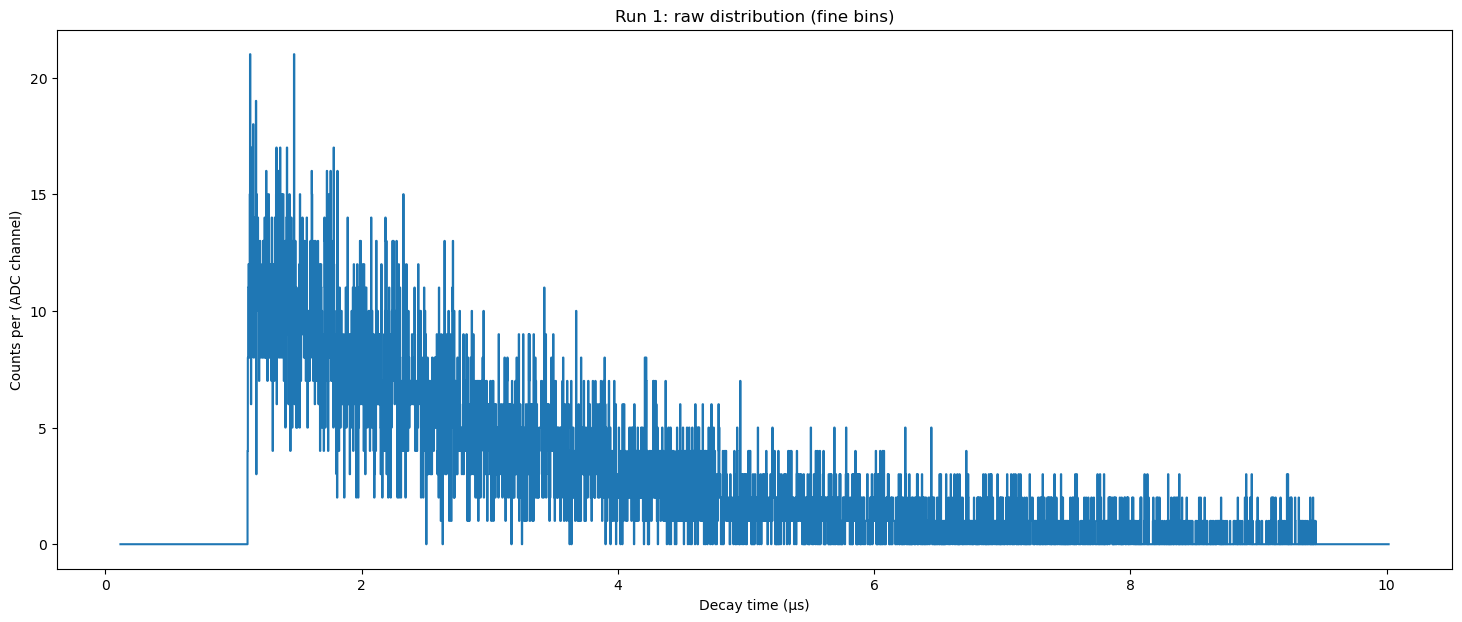


[Run 1] BINNING SCAN (B=0 fit)
Recommended nbins (min |red chi^2-1|): 180
  red chi^2 = 1.067
  tau = 2.15592 ± 0.026 μs


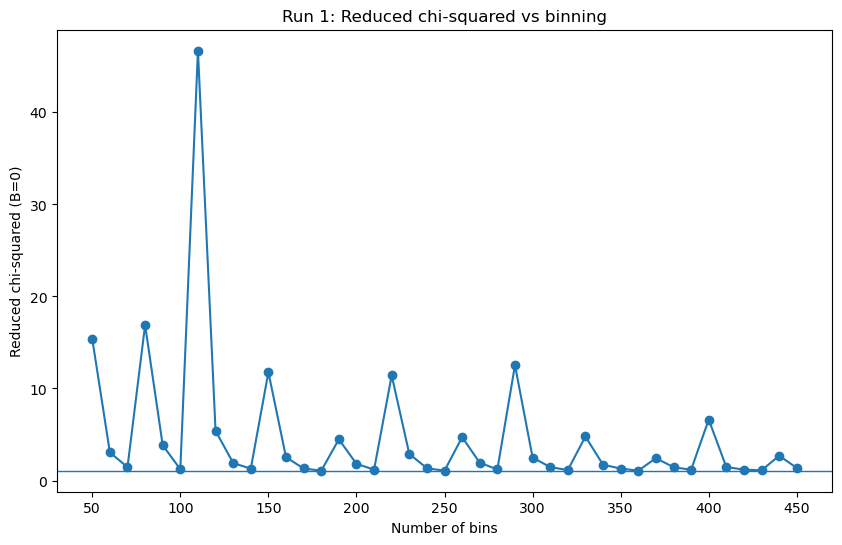

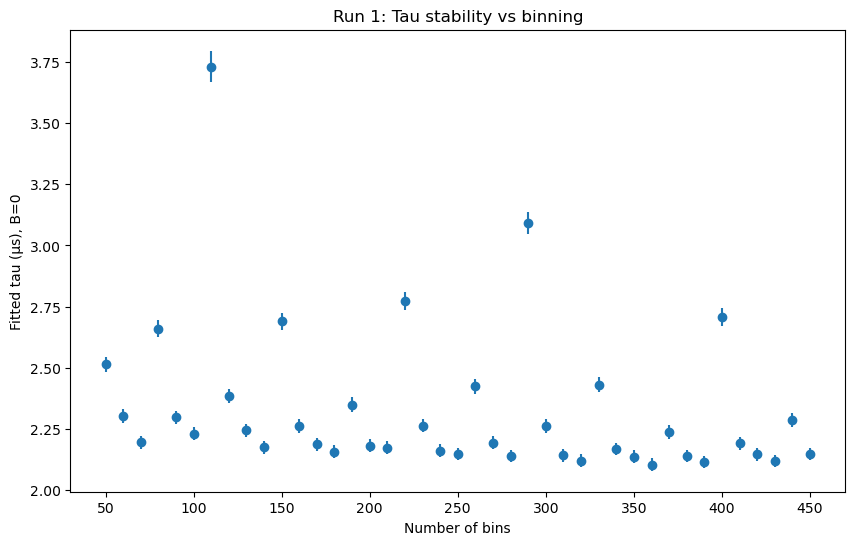

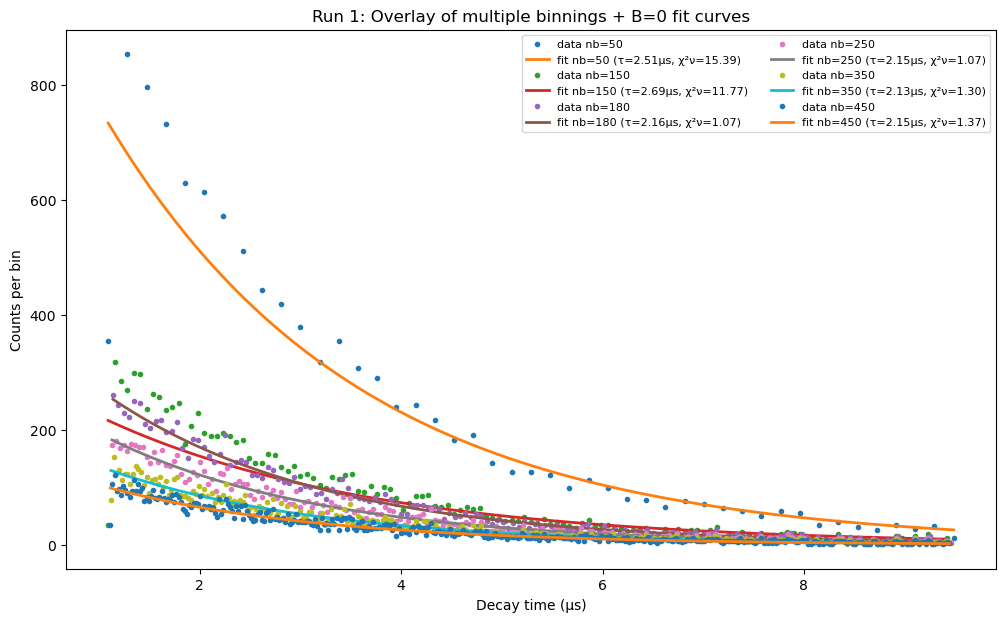


[Run 1] BINNING CHOICE
User nbins = 200
Optimized nbins (closest χ²ν to 1) = 180
Using nbins_used = 180 (use_optimized_binning=True)


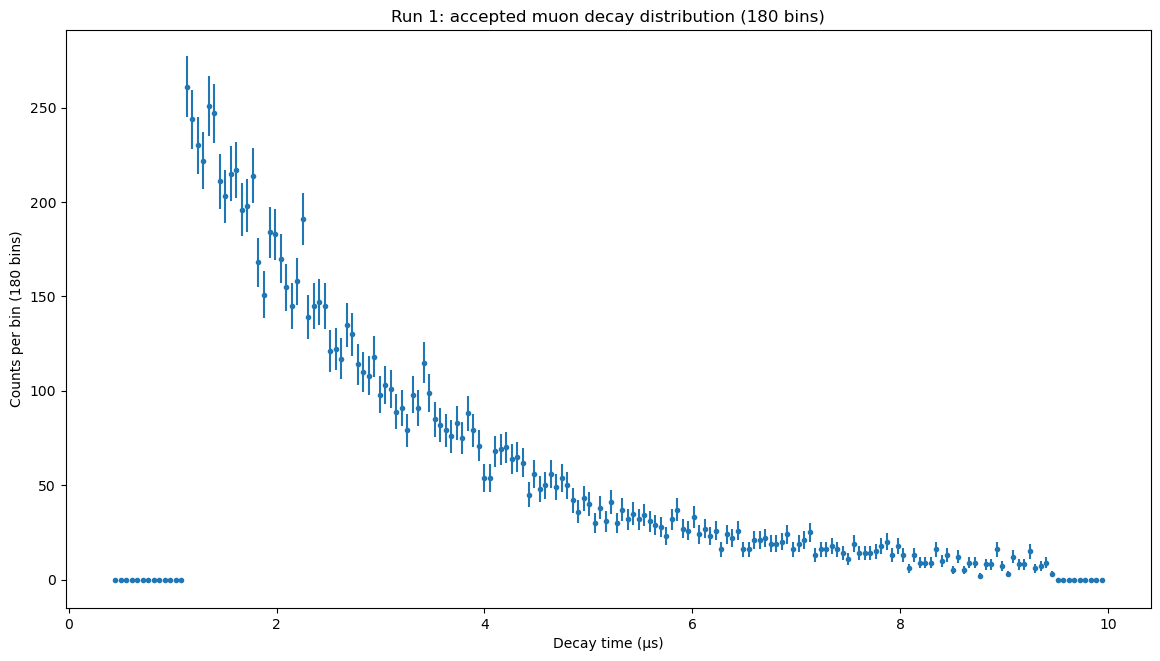

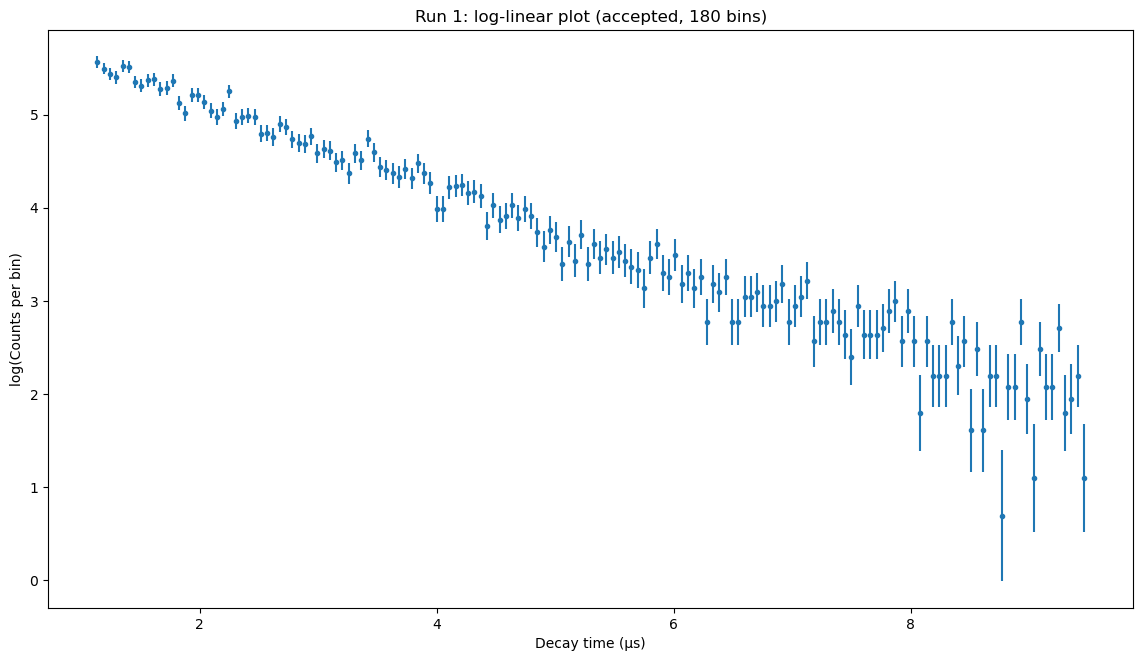


[Run 1] FIT COMPARISON (nbins_used = 180)
Model (B=0): y = A exp(-t/tau)
  A   = 428.92 ± 8.6
  tau = 2.15592 ± 0.026 μs   (95% ± 0.051 μs)
  chi^2 = 166.387, dof = 156, reduced chi^2 = 1.067
Model (B free): y = A exp(-t/tau) + B  with B>=0
  A   = 432.081 ± 11
  tau = 2.13576 ± 0.05 μs   (95% ± 0.098 μs)
  B   = 0.398001 ± 0.85 counts/bin
  chi^2 = 166.171, dof = 155, reduced chi^2 = 1.072
Nested-model test (does adding B significantly improve fit?)
  Δchi^2 = 0.216 with Δdof = 1  =>  p = 0.642
  Interpretation: No significant improvement from B; fixing B=0 is justified.


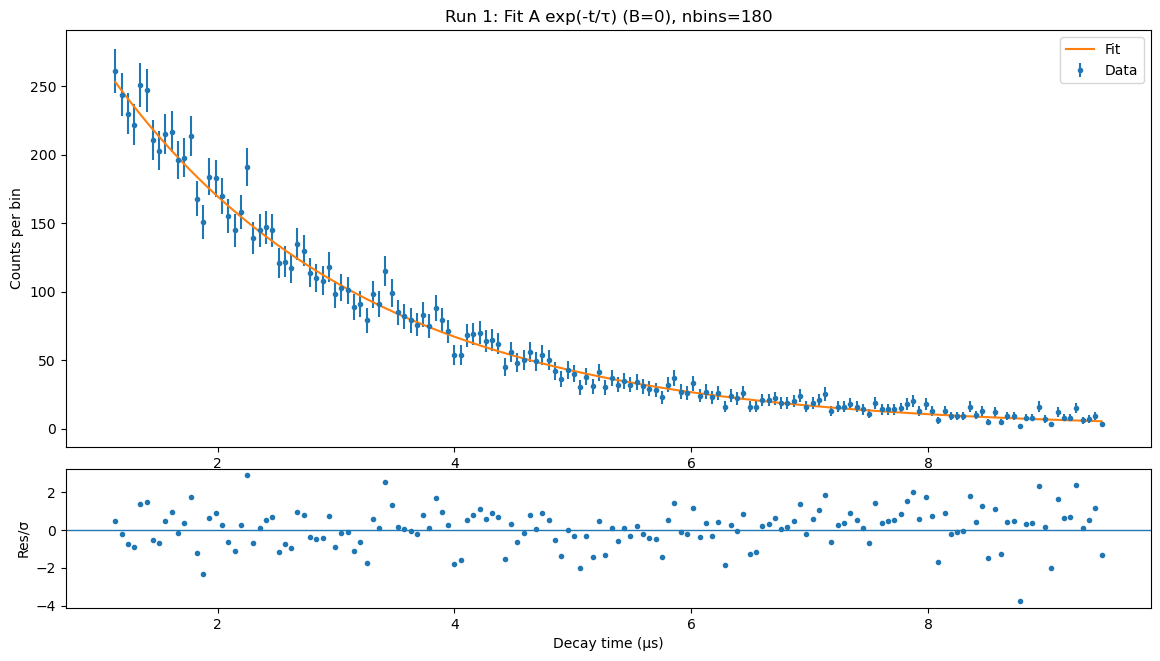

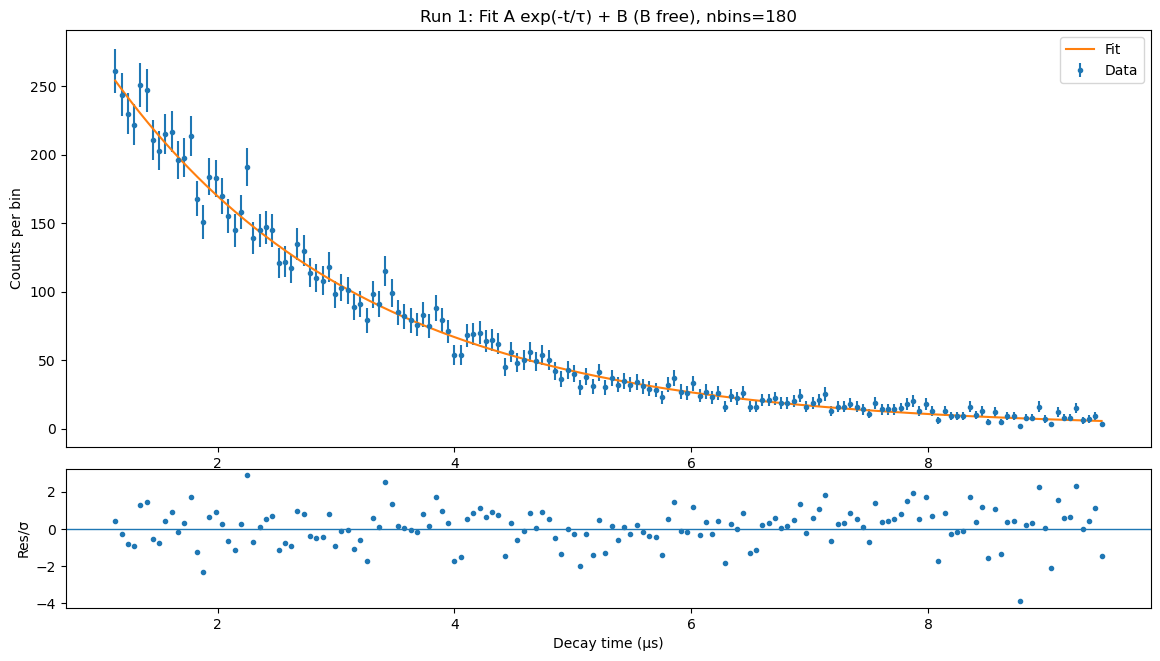

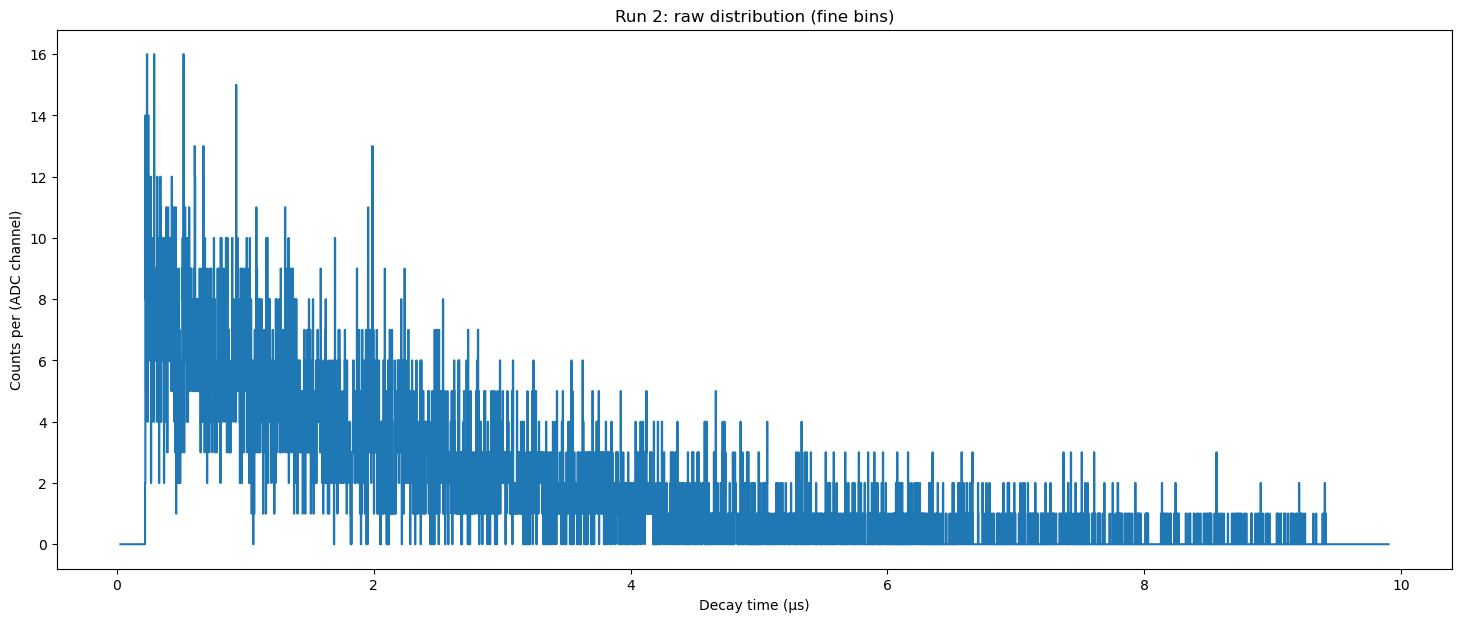


[Run 2] BINNING SCAN (B=0 fit)
Recommended nbins (min |red chi^2-1|): 310
  red chi^2 = 0.979
  tau = 2.13008 ± 0.031 μs


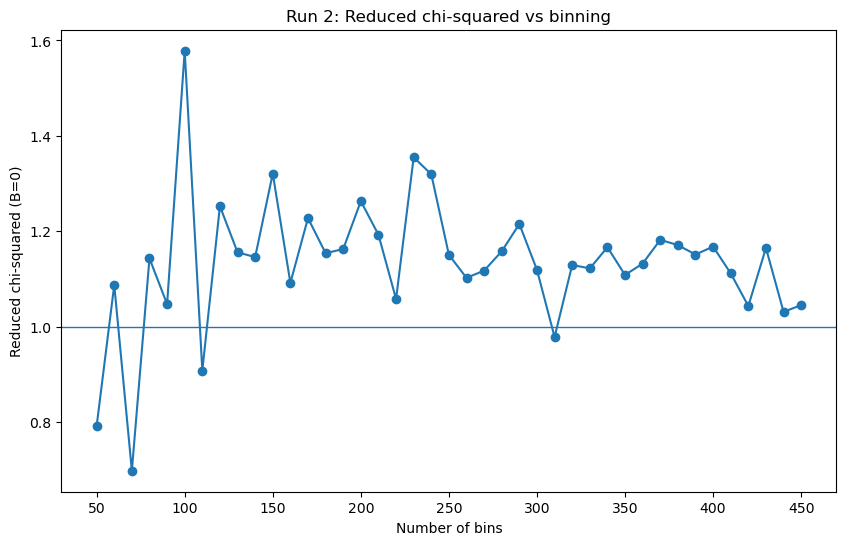

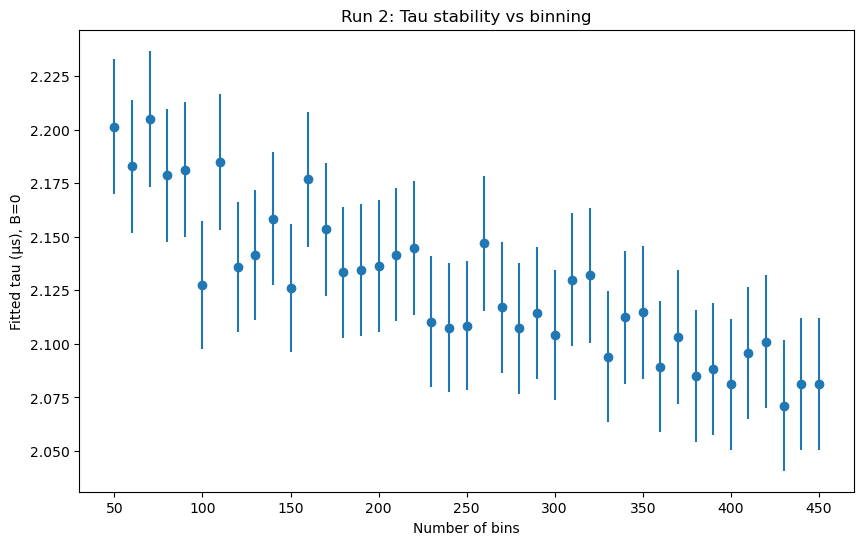

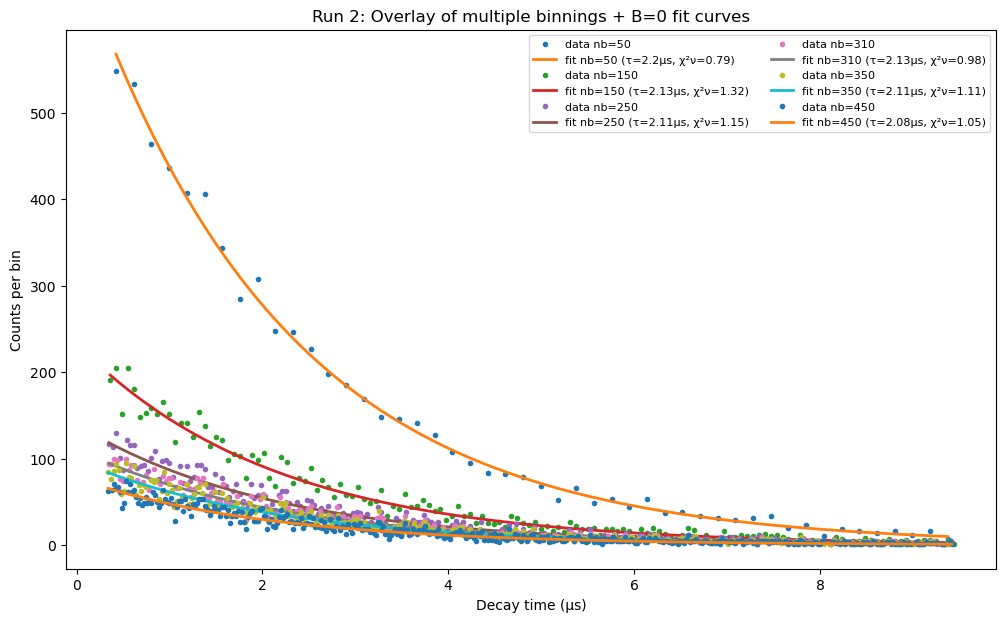


[Run 2] BINNING CHOICE
User nbins = 200
Optimized nbins (closest χ²ν to 1) = 310
Using nbins_used = 310 (use_optimized_binning=True)


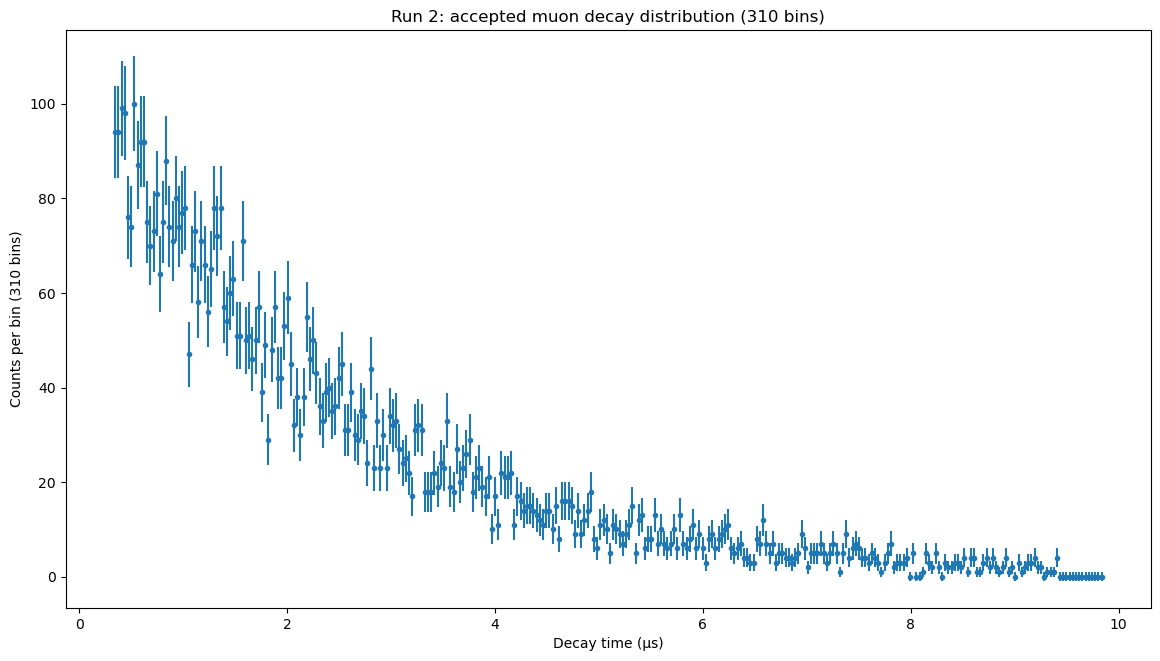

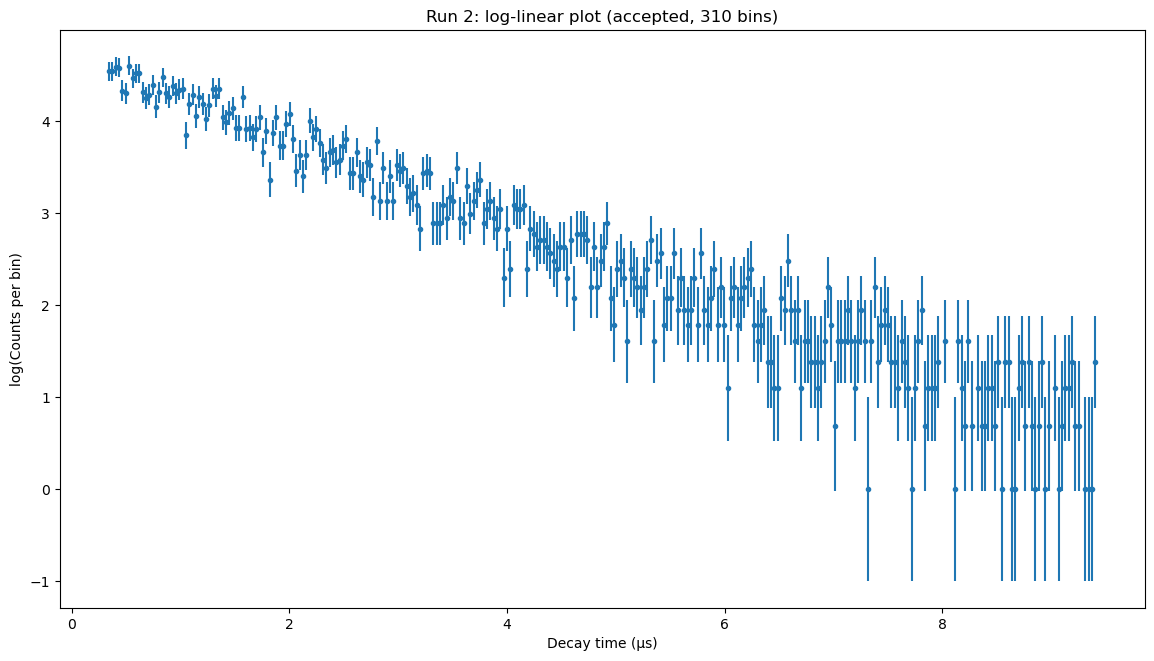


[Run 2] FIT COMPARISON (nbins_used = 310)
Model (B=0): y = A exp(-t/tau)
  A   = 111.221 ± 2.2
  tau = 2.13008 ± 0.031 μs   (95% ± 0.061 μs)
  chi^2 = 281.827, dof = 288, reduced chi^2 = 0.979
Model (B free): y = A exp(-t/tau) + B  with B>=0
  A   = 111.848 ± 2.5
  tau = 2.10438 ± 0.055 μs   (95% ± 0.11 μs)
  B   = 0.171374 ± 0.3 counts/bin
  chi^2 = 281.507, dof = 287, reduced chi^2 = 0.981
Nested-model test (does adding B significantly improve fit?)
  Δchi^2 = 0.320 with Δdof = 1  =>  p = 0.571
  Interpretation: No significant improvement from B; fixing B=0 is justified.


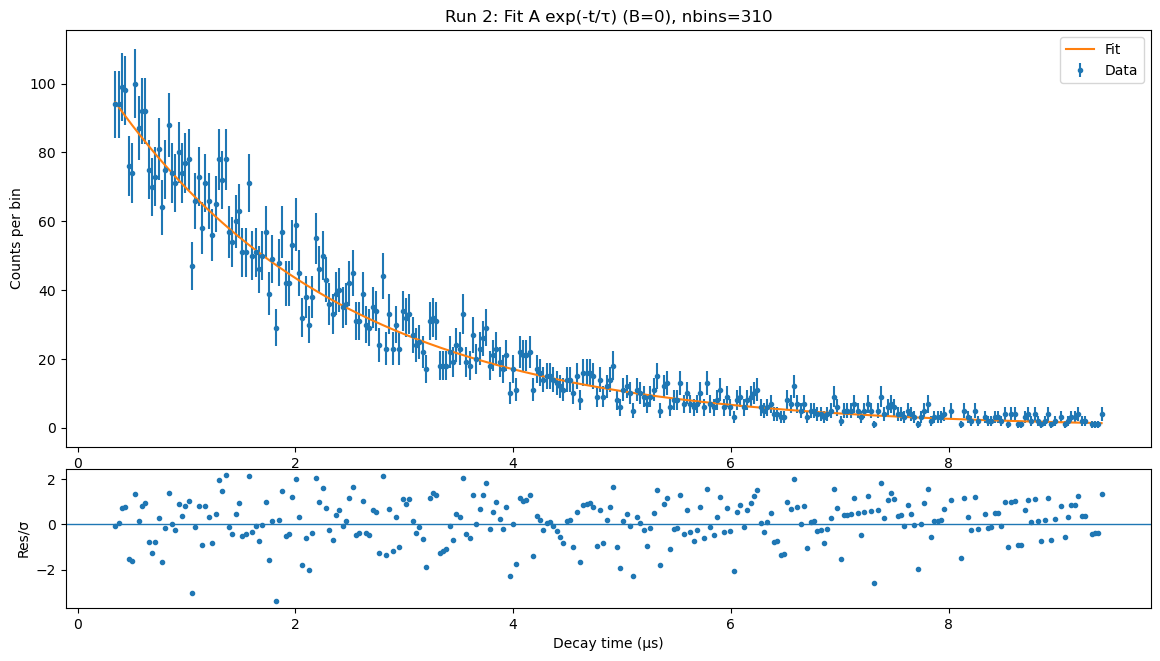

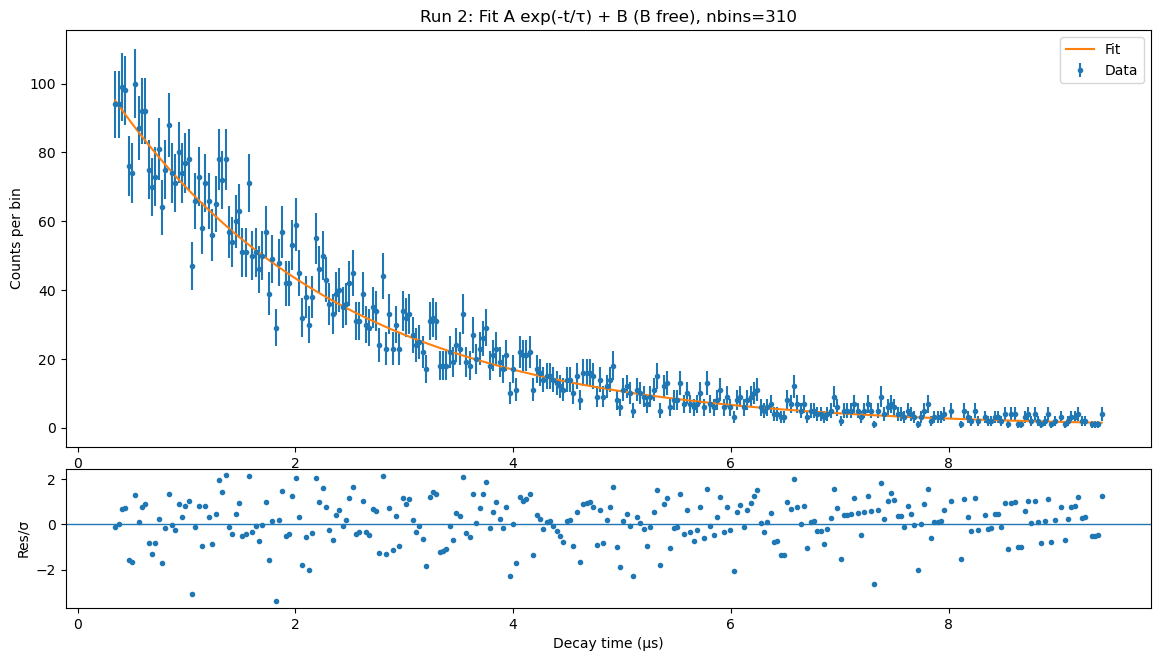


================ Run 1 SUMMARY ================
User nbins = 200
Used nbins = 180
Scan-optimized nbins (closest χ²ν to 1) = 180
Overlay nbins shown = [50, 150, 180, 250, 350, 450]

(B=0) Fit: y = A exp(-t/tau)
  tau = 2.15592 ± 0.026 μs  (95% ± 0.051 μs)
  red chi^2 = 1.067  (chi^2=166.387, dof=156)

(B free) Fit: y = A exp(-t/tau) + B
  B   = 0.398001 ± 0.85 counts/bin
  red chi^2 = 1.072  (chi^2=166.171, dof=155)

Nested-model test (B=0 vs B free):
  Δchi^2 = 0.216 with Δdof = 1  => p = 0.642

================ Run 2 SUMMARY ================
User nbins = 200
Used nbins = 310
Scan-optimized nbins (closest χ²ν to 1) = 310
Overlay nbins shown = [50, 150, 250, 310, 350, 450]

(B=0) Fit: y = A exp(-t/tau)
  tau = 2.13008 ± 0.031 μs  (95% ± 0.061 μs)
  red chi^2 = 0.979  (chi^2=281.827, dof=288)

(B free) Fit: y = A exp(-t/tau) + B
  B   = 0.171374 ± 0.3 counts/bin
  red chi^2 = 0.981  (chi^2=281.507, dof=287)

Nested-model test (B=0 vs B free):
  Δchi^2 = 0.320 with Δdof = 1  => p = 0.571

In [51]:
# -----------------------------
# RESULTS
# -----------------------------

# Toggle this if you want the final reported fits to use the optimized binning:
USE_OPTIMIZED_BINNING = True

res1 = analyze_muon_run(
    run_label="Run 1",
    data_path="data/RUN1 JAN 30-FEB 3 2026.txt",
    cal_m=cal_m1,
    cal_b=cal_b1,
    out_dir="plots/run 1",
    adc_cut=(125, 4075),
    nbins=NBINS_MAIN,
    nbins_scan_grid=NBINS_SCAN_GRID,
    use_optimized_binning=USE_OPTIMIZED_BINNING
)

res2 = analyze_muon_run(
    run_label="Run 2",
    data_path="data/RUN2 FEB 3-FEB 6 2026.txt",
    cal_m=cal_m2,
    cal_b=cal_b2,
    out_dir="plots/run 2",
    adc_cut=(125, 4075),
    nbins=NBINS_MAIN,
    nbins_scan_grid=NBINS_SCAN_GRID,
    use_optimized_binning=USE_OPTIMIZED_BINNING
)

def print_summary(res):
    rl = res["run_label"]
    b0 = res["B0"]
    bf = res["Bfree"]
    print(f"\n================ {rl} SUMMARY ================")
    print(f"User nbins = {res['nbins_user']}")
    print(f"Used nbins = {res['nbins_used']}")
    print(f"Scan-optimized nbins (closest χ²ν to 1) = {res['binning_scan_best_nbins']}")
    print(f"Overlay nbins shown = {res['binning_overlay_nbins']}")
    print("\n(B=0) Fit: y = A exp(-t/tau)")
    print(f"  tau = {b0['tau_us']:.6g} ± {b0['tau_err_us']:.2g} μs  (95% ± {1.96*b0['tau_err_us']:.2g} μs)")
    print(f"  red chi^2 = {b0['red_chi2']:.3f}  (chi^2={b0['chi2']:.3f}, dof={b0['dof']})")
    print("\n(B free) Fit: y = A exp(-t/tau) + B")
    print(f"  B   = {bf['B']:.6g} ± {bf['B_err']:.2g} counts/bin")
    print(f"  red chi^2 = {bf['red_chi2']:.3f}  (chi^2={bf['chi2']:.3f}, dof={bf['dof']})")
    print("\nNested-model test (B=0 vs B free):")
    print(f"  Δchi^2 = {bf['delta_chi2']:.3f} with Δdof = {bf['delta_dof']}  => p = {bf['p_value']:.3g}")

print_summary(res1)
print_summary(res2)

# Save scan tables (appendix / reproducibility)
Path("plots").mkdir(exist_ok=True)
res1["binning_scan_df"].to_csv("plots/run1_binning_scan.csv", index=False)
res2["binning_scan_df"].to_csv("plots/run2_binning_scan.csv", index=False)